# Produttivita apparente per settore SBS

Questo notebook riprende il foglio `value_added_by_macro_sector_italy_eurostat.ipynb`, lo traduce in italiano e lo integra nella struttura di questo repo.

Il punto centrale e il valore aggiunto per persona occupata, cioe l'indicatore Eurostat `LABPRY_TEUR` del dataset Structural Business Statistics. L'indicatore e gia pubblicato dalla fonte in migliaia di euro per persona occupata: non viene stimato dal notebook e non va sommato tra classi o settori.

Nel progetto questo foglio serve anche a chiarire una differenza importante: il rapporto calcolato manualmente da valore aggiunto e occupati puo non coincidere con `LABPRY_TEUR` quando alcune celle dimensionali hanno dati mancanti, riservati o non pubblicati.

In [1]:
from pathlib import Path
import sys

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from IPython.display import display

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from valore_aggiunto_imprese.analysis import enrich_sbs, read_project_csv

pd.options.display.max_columns = 80
pd.options.display.float_format = "{:,.2f}".format

plt.rcParams.update(
    {
        "figure.figsize": (12, 7),
        "axes.facecolor": "white",
        "figure.facecolor": "white",
        "axes.edgecolor": "#1f2937",
        "axes.labelcolor": "#1f2937",
        "xtick.color": "#1f2937",
        "ytick.color": "#1f2937",
        "grid.color": "#d1d5db",
        "grid.linestyle": "--",
        "grid.linewidth": 0.8,
    }
)

FONTE_SBS = "Eurostat Structural Business Statistics (sbs_sc_ovw)"
FONTE_PRODUTTIVITA = "Eurostat Structural Business Statistics (sbs_sc_ovw, LABPRY_TEUR)"
IND_PRODUTTIVITA = "LABPRY_TEUR"
IND_VALORE_AGGIUNTO = "AV_MEUR"
IND_OCCUPATI = "EMP_NR"
CLASSE_TOTALE = "TOTAL"
ITALIA = "IT"
COLORI = ["#2a7ab9", "#f28e2b", "#59a14f", "#e15759", "#76b7b2", "#edc948", "#b07aa1", "#ff9da7", "#9c755f", "#bab0ac"]


def formato_numero_it(valore, decimali=1):
    testo = f"{valore:,.{decimali}f}"
    return testo.replace(",", "X").replace(".", ",").replace("X", ".")


def asse_migliaia_euro(x, _pos):
    return formato_numero_it(x, 0)


def aggiungi_fonte(ax, fonte=FONTE_PRODUTTIVITA):
    ax.figure.text(
        0.06,
        0.025,
        f"Fonte: {fonte}. Elaborazione di Nazareno Lecis.",
        ha="left",
        va="bottom",
        fontsize=9,
        color="#374151",
    )


def rifinisci_grafico(ax, titolo, asse_y, formato_asse="y", asse_griglia="y"):
    ax.set_title(titolo, loc="left", fontsize=15, pad=16, color="#1f2937")
    ax.set_ylabel(asse_y)
    ax.grid(axis=asse_griglia)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    if formato_asse == "y":
        ax.yaxis.set_major_formatter(FuncFormatter(asse_migliaia_euro))
    elif formato_asse == "x":
        ax.xaxis.set_major_formatter(FuncFormatter(asse_migliaia_euro))

## Base dati del repo

Il notebook non scarica dati in autonomia. Usa il CSV pulito prodotto dalla pipeline locale, cosi le analisi restano allineate al resto del progetto.

Se il file non e presente, eseguire prima `python -m valore_aggiunto_imprese.pipeline`.

In [2]:
sbs = enrich_sbs(read_project_csv("data/processed/official_eurostat_sbs.csv"))
sbs = sbs.dropna(subset=["year"]).copy()
sbs["year"] = sbs["year"].astype(int)
sbs["value"] = pd.to_numeric(sbs["value"], errors="coerce")

produttivita = sbs.query("metric_code == @IND_PRODUTTIVITA").dropna(subset=["value"])
produttivita_totale = produttivita.query("size_class_original == @CLASSE_TOTALE")

sintesi = pd.DataFrame(
    [
        {"voce": "Righe SBS", "valore": len(sbs)},
        {"voce": "Paesi", "valore": sbs["country_code"].nunique()},
        {"voce": "Anni", "valore": f'{sbs["year"].min()}-{sbs["year"].max()}'},
        {"voce": "Settori NACE", "valore": sbs["sector_code_original"].nunique()},
        {"voce": "Classi dimensionali", "valore": sbs["size_class_original"].nunique()},
        {"voce": "Righe con produttivita ufficiale", "valore": len(produttivita)},
    ]
)

sintesi

,voce,valore
0,Righe SBS,314280
1,Paesi,27
2,Anni,2021-2024
3,Settori NACE,97
4,Classi dimensionali,6
5,Righe con produttivita ufficiale,36117


## Indicatori disponibili

La produttivita apparente e un indicatore distinto dal valore aggiunto totale e dagli occupati. Questa distinzione e rilevante per la dashboard: quando Eurostat pubblica `LABPRY_TEUR`, e preferibile usare quello invece di ricostruire il rapporto da altre due variabili.

In [3]:
indicatori = (
    sbs.groupby(["metric_code", "metric_label_readable"], observed=True)
    .agg(righe=("value", "size"), valori_presenti=("value", "count"))
    .reset_index()
    .sort_values("metric_code")
)

indicatori

,metric_code,metric_label_readable,righe,valori_presenti
0,AV_MEUR,Valore aggiunto (mln euro),62856,39476
1,EMP_NR,Persone occupate,62856,55412
2,ENT_NR,Imprese,62856,59613
3,LABPRY_TEUR,Produttivita apparente (migliaia euro),62856,36117
4,SAL_NR,Dipendenti,62856,21772


## Settori italiani selezionati

Questa vista replica il nucleo del notebook originale: confronto tra alcuni settori italiani nel 2023, usando `LABPRY_TEUR` e la classe `TOTAL`.

La media SBS non e il PIL nazionale: e il perimetro Eurostat SBS indicato dal codice `B-S_X_O_S94`, cioe industria, costruzioni e servizi di mercato con alcune esclusioni istituzionali.

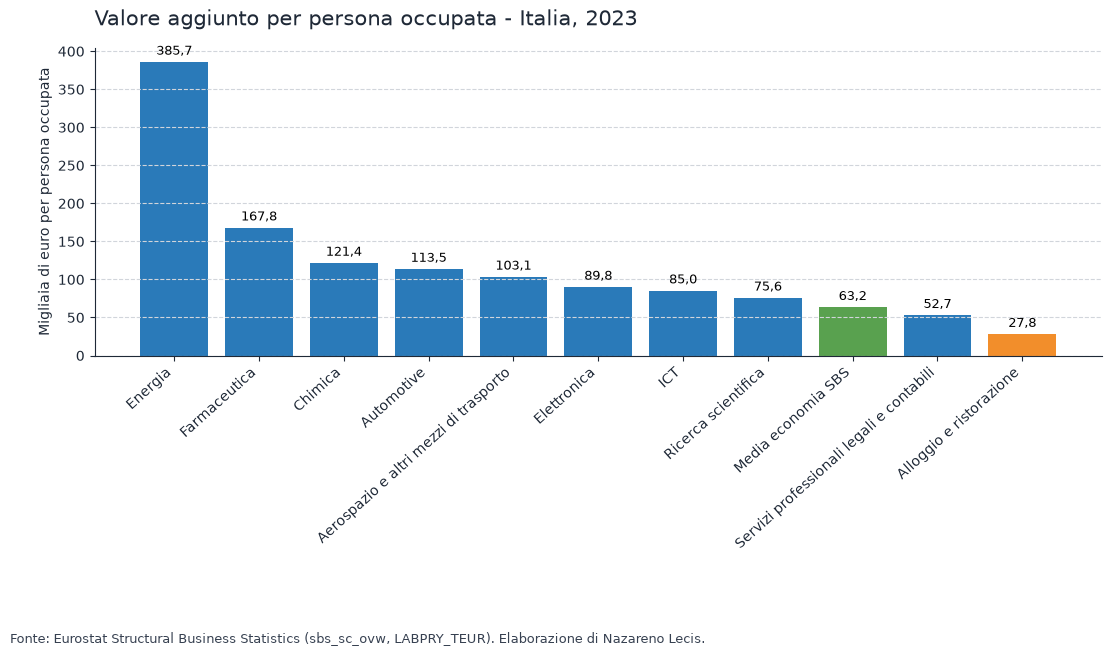

,codice,settore,migliaia_euro_per_persona_occupata
43462,D,Energia,385.67
145846,C21,Farmaceutica,167.80
145198,C20,Chimica,121.44
151030,C29,Automotive,113.45
151678,C30,Aerospazio e altri mezzi di trasporto,103.14
149086,C26,Elettronica,89.85
47350,J,ICT,85.00
257302,M72,Ricerca scientifica,75.58
41518,B-S_X_O_S94,Media economia SBS,63.22
255358,M69,Servizi professionali legali e contabili,52.69


In [4]:
anno_riferimento = 2023
settori_selezionati = {
    "D": "Energia",
    "C21": "Farmaceutica",
    "C20": "Chimica",
    "C29": "Automotive",
    "C30": "Aerospazio e altri mezzi di trasporto",
    "C26": "Elettronica",
    "J": "ICT",
    "M72": "Ricerca scientifica",
    "B-S_X_O_S94": "Media economia SBS",
    "M69": "Servizi professionali legali e contabili",
    "I": "Alloggio e ristorazione",
}

anni_disponibili = sorted(
    produttivita_totale.query(
        "country_code == @ITALIA and sector_code_original in @settori_selezionati.keys()"
    )["year"].dropna().unique()
)
if anno_riferimento not in anni_disponibili:
    anno_riferimento = max(anni_disponibili)

italia_settori = (
    produttivita_totale.query(
        "country_code == @ITALIA and year == @anno_riferimento and sector_code_original in @settori_selezionati.keys()"
    )
    .loc[:, ["sector_code_original", "value"]]
    .assign(settore=lambda df: df["sector_code_original"].map(settori_selezionati))
)
ordine = list(settori_selezionati.keys())
italia_settori["ordine"] = italia_settori["sector_code_original"].map({codice: i for i, codice in enumerate(ordine)})
italia_settori = italia_settori.sort_values("ordine")

colori_barre = [
    "#59a14f" if codice == "B-S_X_O_S94" else "#f28e2b" if codice == "I" else "#2a7ab9"
    for codice in italia_settori["sector_code_original"]
]

fig, ax = plt.subplots(figsize=(13, 7))
barre = ax.bar(italia_settori["settore"], italia_settori["value"], color=colori_barre)
rifinisci_grafico(
    ax,
    f"Valore aggiunto per persona occupata - Italia, {anno_riferimento}",
    "Migliaia di euro per persona occupata",
)
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=42)
for label in ax.get_xticklabels():
    label.set_horizontalalignment("right")
for barra in barre:
    valore = barra.get_height()
    ax.text(
        barra.get_x() + barra.get_width() / 2,
        valore + max(italia_settori["value"]) * 0.015,
        formato_numero_it(valore, 1),
        ha="center",
        va="bottom",
        fontsize=9,
    )
aggiungi_fonte(ax)
fig.subplots_adjust(bottom=0.44)
plt.show()

italia_settori[["sector_code_original", "settore", "value"]].rename(
    columns={"sector_code_original": "codice", "value": "migliaia_euro_per_persona_occupata"}
)

## Perche il rapporto ricostruito puo differire

Per alcuni settori, usare `AV_MEUR / EMP_NR` sulle sole classi dimensionali disponibili produce risultati diversi dall'indicatore ufficiale. Il motivo non e metodologico ma informativo: valore aggiunto e occupati non hanno sempre la stessa copertura pubblicata per tutte le classi.

La tabella sotto mostra il confronto sui settori del grafico precedente. Quando mancano celle di valore aggiunto per alcune classi, il rapporto ricostruito tende a essere meno affidabile.

In [5]:
classi_sbs = ["0-9", "10-19", "20-49", "50-249", "GE250"]
confronto_codici = list(settori_selezionati.keys())

ufficiale = (
    produttivita_totale.query(
        "country_code == @ITALIA and year == @anno_riferimento and sector_code_original in @confronto_codici"
    )
    .loc[:, ["sector_code_original", "value"]]
    .rename(columns={"value": "produttivita_ufficiale_labpry"})
)

valore_classi = sbs.query(
    "country_code == @ITALIA and year == @anno_riferimento and metric_code == @IND_VALORE_AGGIUNTO and size_class_original in @classi_sbs and sector_code_original in @confronto_codici"
)
occupati_classi = sbs.query(
    "country_code == @ITALIA and year == @anno_riferimento and metric_code == @IND_OCCUPATI and size_class_original in @classi_sbs and sector_code_original in @confronto_codici"
)

valore_somma = (
    valore_classi.groupby("sector_code_original", observed=True)
    .agg(valore_aggiunto_mln=("value", "sum"), classi_valore_aggiunto=("value", "count"))
    .reset_index()
)
occupati_somma = (
    occupati_classi.groupby("sector_code_original", observed=True)
    .agg(occupati=("value", "sum"), classi_occupati=("value", "count"))
    .reset_index()
)

ricostruito = valore_somma.merge(occupati_somma, on="sector_code_original", how="outer")
ricostruito["produttivita_ricostruita"] = ricostruito["valore_aggiunto_mln"] * 1000 / ricostruito["occupati"]

confronto = (
    ufficiale.merge(ricostruito, on="sector_code_original", how="left")
    .assign(
        settore=lambda df: df["sector_code_original"].map(settori_selezionati),
        differenza=lambda df: df["produttivita_ufficiale_labpry"] - df["produttivita_ricostruita"],
        classi_mancanti_valore_aggiunto=lambda df: len(classi_sbs) - df["classi_valore_aggiunto"],
    )
    .loc[:, [
        "sector_code_original",
        "settore",
        "produttivita_ufficiale_labpry",
        "produttivita_ricostruita",
        "differenza",
        "classi_valore_aggiunto",
        "classi_mancanti_valore_aggiunto",
    ]]
    .sort_values("produttivita_ufficiale_labpry", ascending=False)
)

confronto.round(2)

,sector_code_original,settore,produttivita_ufficiale_labpry,produttivita_ricostruita,differenza,classi_valore_aggiunto,classi_mancanti_valore_aggiunto
1,D,Energia,385.67,64.63,321.04,3,2
5,C21,Farmaceutica,167.80,167.80,0.00,5,0
4,C20,Chimica,121.44,121.44,0.00,5,0
7,C29,Automotive,113.45,113.45,-0.00,5,0
8,C30,Aerospazio e altri mezzi di trasporto,103.14,103.14,0.00,5,0
6,C26,Elettronica,89.85,89.85,-0.00,5,0
3,J,ICT,85.00,85.00,-0.00,5,0
10,M72,Ricerca scientifica,75.58,28.61,46.97,3,2
0,B-S_X_O_S94,Media economia SBS,63.22,63.22,0.00,5,0
9,M69,Servizi professionali legali e contabili,52.69,52.69,0.00,5,0


## Turismo proxy per classe dimensionale

Nel dataset SBS non esiste una misura completa del turismo in senso satellite. Qui il turismo e letto come proxy attraverso la sezione NACE `I`, cioe alloggio e ristorazione.

Il grafico confronta Italia, Francia, Germania e Spagna per classe dimensionale. Anche qui si usa `LABPRY_TEUR`, quindi ogni barra e un valore medio per persona occupata pubblicato da Eurostat.

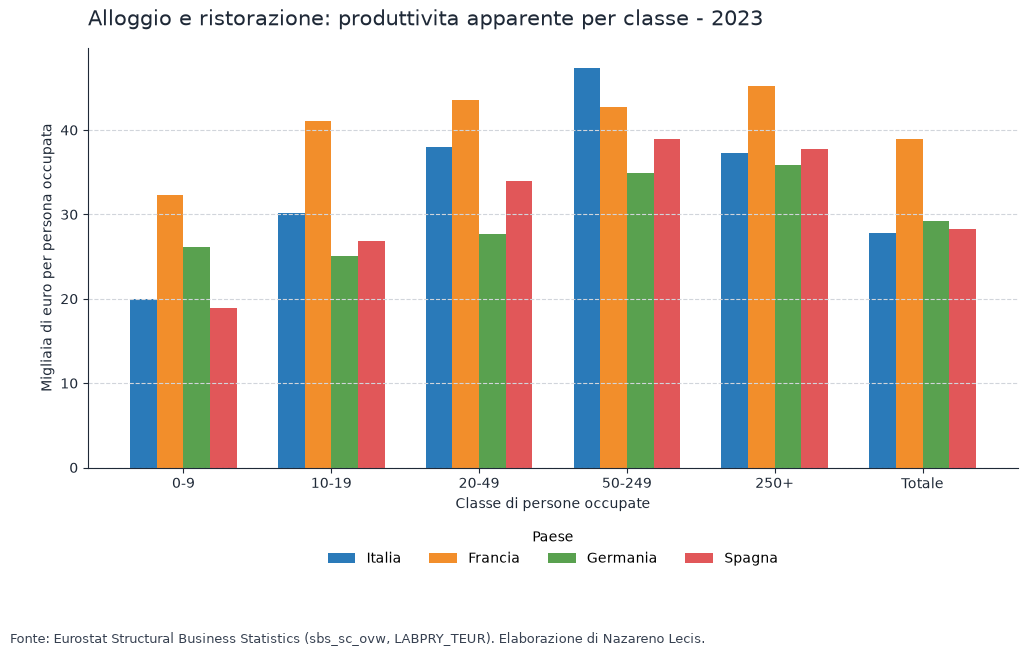

country_label,Francia,Germania,Italia,Spagna
classe,,,,
0-9,32.30,26.10,20.00,18.90
10-19,41.10,25.10,30.10,26.80
20-49,43.50,27.60,38.00,33.90
50-249,42.80,34.90,47.40,39.00
250+,45.20,35.90,37.30,37.80
Totale,38.90,29.30,27.80,28.30


In [6]:
paesi_turismo = ["IT", "FR", "DE", "ES"]
classi_turismo = ["0-9", "10-19", "20-49", "50-249", "GE250", "TOTAL"]
etichette_classi = {
    "0-9": "0-9",
    "10-19": "10-19",
    "20-49": "20-49",
    "50-249": "50-249",
    "GE250": "250+",
    "TOTAL": "Totale",
}

base_turismo = produttivita.query(
    "country_code in @paesi_turismo and sector_code_original == 'I' and size_class_original in @classi_turismo"
)

anno_turismo = None
for anno in sorted(base_turismo["year"].unique(), reverse=True):
    pivot = base_turismo.query("year == @anno").pivot_table(
        index="size_class_original",
        columns="country_code",
        values="value",
        aggfunc="first",
        observed=True,
    )
    if all(paese in pivot.columns for paese in paesi_turismo) and all(classe in pivot.index for classe in classi_turismo):
        if pivot.loc[classi_turismo, paesi_turismo].notna().all().all():
            anno_turismo = int(anno)
            break
if anno_turismo is None:
    anno_turismo = int(base_turismo["year"].max())

plot_turismo = (
    base_turismo.query("year == @anno_turismo")
    .assign(classe=lambda df: df["size_class_original"].map(etichette_classi))
    .copy()
)
plot_turismo["classe"] = pd.Categorical(plot_turismo["classe"], [etichette_classi[c] for c in classi_turismo], ordered=True)

fig, ax = plt.subplots(figsize=(12, 7))
larghezza = 0.18
x = range(len(classi_turismo))
for indice, paese in enumerate(paesi_turismo):
    dati_paese = (
        plot_turismo.query("country_code == @paese")
        .set_index("size_class_original")
        .reindex(classi_turismo)
    )
    posizioni = [i + (indice - 1.5) * larghezza for i in x]
    ax.bar(posizioni, dati_paese["value"], width=larghezza, label=dati_paese["country_label"].dropna().iloc[0], color=COLORI[indice])

rifinisci_grafico(
    ax,
    f"Alloggio e ristorazione: produttivita apparente per classe - {anno_turismo}",
    "Migliaia di euro per persona occupata",
)
ax.set_xticks(list(x))
ax.set_xticklabels([etichette_classi[c] for c in classi_turismo])
ax.set_xlabel("Classe di persone occupate")
ax.legend(title="Paese", frameon=False, ncol=4, loc="upper center", bbox_to_anchor=(0.5, -0.12))
aggiungi_fonte(ax)
fig.subplots_adjust(bottom=0.28)
plt.show()

plot_turismo.pivot_table(
    index="classe",
    columns="country_label",
    values="value",
    aggfunc="first",
    observed=True,
).round(1)

## Panoramica settoriale ampia

Per dare una lettura piu completa non basta guardare i settori citati come esempi. Qui vengono ordinati tutti i settori disponibili per l'Italia nell'ultimo anno con dati SBS completi sulla classe totale.

La vista mette insieme sezioni e divisioni NACE: e utile per esplorare, ma non bisogna sommare questi valori perche alcune divisioni sono sottoinsiemi delle rispettive sezioni.

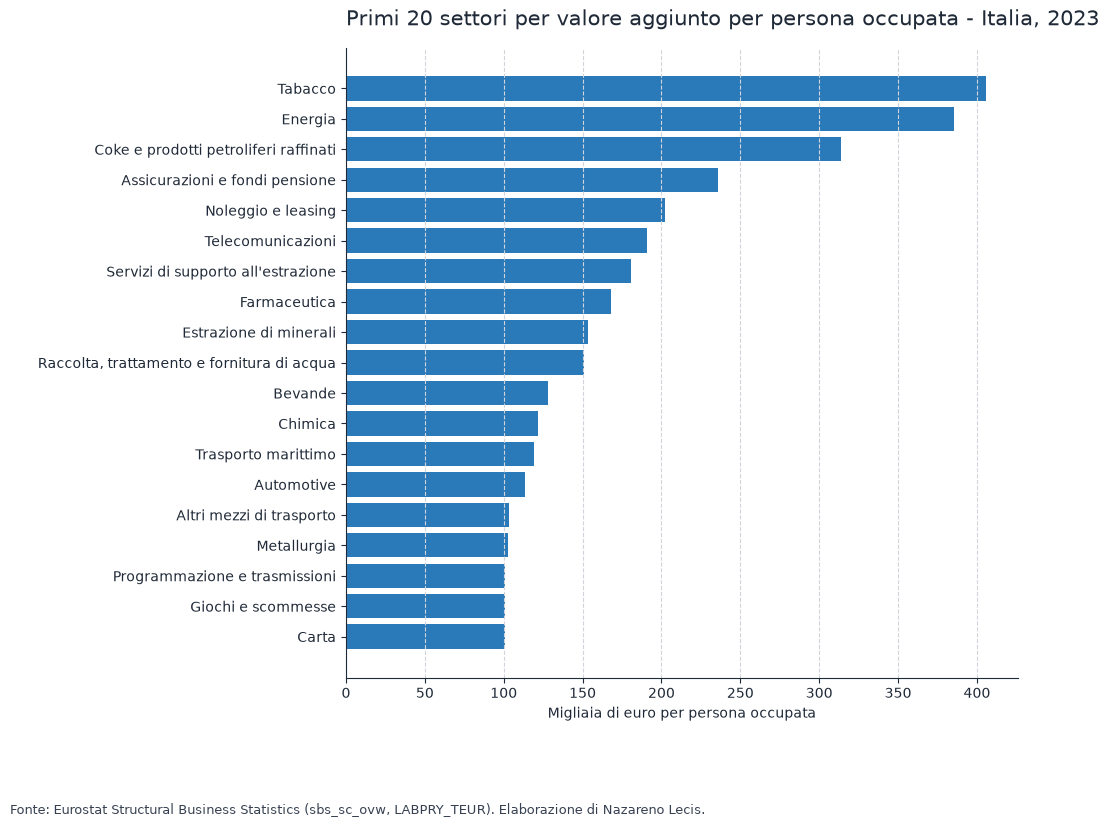

,sector_code_original,sector_label,value
97894,C12,Tabacco,405.70
43462,D,Energia,385.70
154270,D35,Energia,385.70
102430,C19,Coke e prodotti petroliferi raffinati,313.80
253414,K65,Assicurazioni e fondi pensione,235.90
301366,N77,Noleggio e leasing,202.10
250822,J61,Telecomunicazioni,190.70
95950,B09,Servizi di supporto all'estrazione,180.90
145846,C21,Farmaceutica,167.80
42166,B,Estrazione di minerali,153.40


In [7]:
anno_italia_massimo = int(produttivita_totale.query("country_code == @ITALIA")["year"].max())
italia_tutti_settori = (
    produttivita_totale.query("country_code == @ITALIA and year == @anno_italia_massimo")
    .loc[:, ["sector_code_original", "sector_label", "value"]]
    .dropna(subset=["value"])
    .sort_values("value", ascending=False)
)

fig, ax = plt.subplots(figsize=(12, 9))
primi = italia_tutti_settori.head(20).sort_values("value")
ax.barh(primi["sector_label"], primi["value"], color="#2a7ab9")
rifinisci_grafico(
    ax,
    f"Primi 20 settori per valore aggiunto per persona occupata - Italia, {anno_italia_massimo}",
    "",
    formato_asse="x",
    asse_griglia="x",
)
ax.set_xlabel("Migliaia di euro per persona occupata")
ax.set_ylabel("")
aggiungi_fonte(ax)
fig.subplots_adjust(left=0.34, bottom=0.18)
plt.show()

italia_tutti_settori.head(20).round(1)

## Settori con produttivita piu bassa

La parte bassa della distribuzione e altrettanto importante della parte alta: mostra dove il valore aggiunto per persona occupata e piu contenuto. In questi settori possono pesare lavoro a bassa marginalita, alta intensita di personale o prezzi di mercato piu bassi.

La lettura resta descrittiva: il dato non misura qualita del lavoro, salari, profitti o condizioni contrattuali.

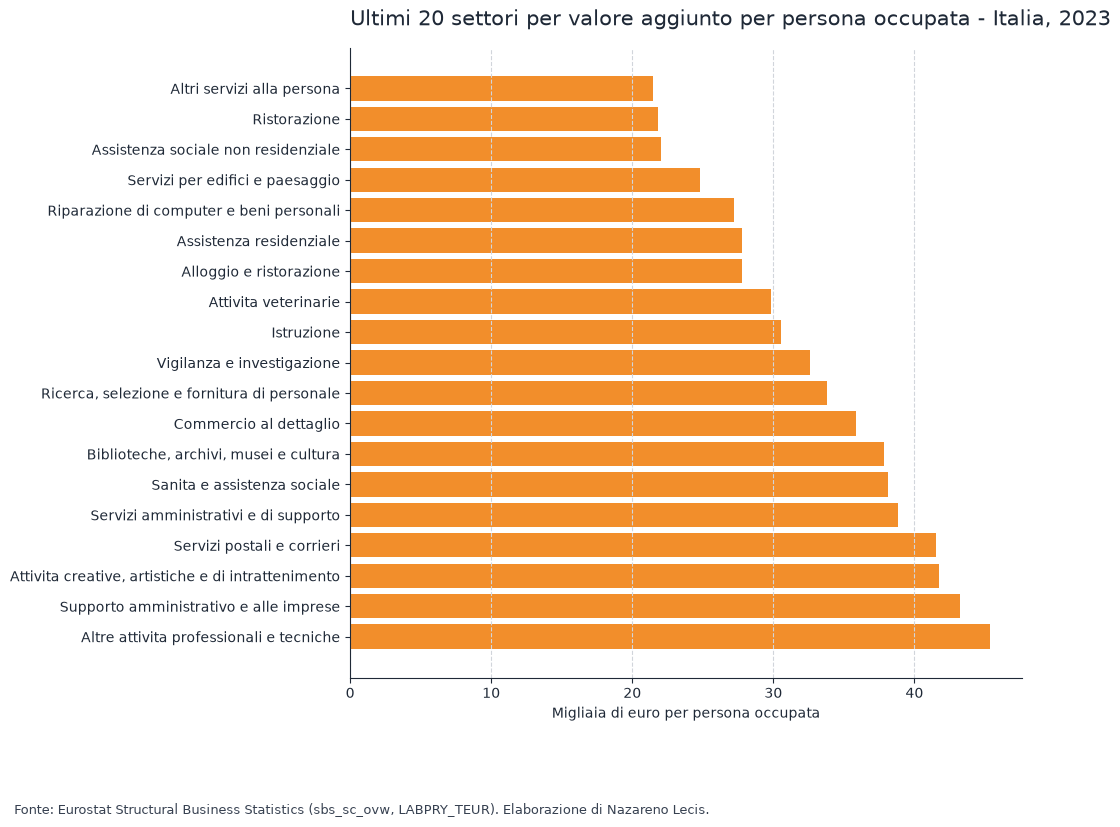

,sector_code_original,sector_label,value
258598,M74,Altre attivita professionali e tecniche,45.40
304606,N82,Supporto amministrativo e alle imprese,43.20
307846,R90,"Attivita creative, artistiche e di intrattenim...",41.70
205462,H53,Servizi postali e corrieri,41.50
49942,N,Servizi amministrativi e di supporto,38.80
51238,Q,Sanita e assistenza sociale,38.10
308494,R91,"Biblioteche, archivi, musei e cultura",37.80
202222,G47,Commercio al dettaglio,35.90
302014,N78,"Ricerca, selezione e fornitura di personale",33.80
303310,N80,Vigilanza e investigazione,32.60


In [8]:
ultimi = italia_tutti_settori.tail(20).sort_values("value", ascending=False)

fig, ax = plt.subplots(figsize=(12, 9))
ax.barh(ultimi["sector_label"], ultimi["value"], color="#f28e2b")
rifinisci_grafico(
    ax,
    f"Ultimi 20 settori per valore aggiunto per persona occupata - Italia, {anno_italia_massimo}",
    "",
    formato_asse="x",
    asse_griglia="x",
)
ax.set_xlabel("Migliaia di euro per persona occupata")
ax.set_ylabel("")
aggiungi_fonte(ax)
fig.subplots_adjust(left=0.34, bottom=0.18)
plt.show()

italia_tutti_settori.tail(20).round(1)

## Serie storiche dei settori selezionati

La serie storica usa sempre lo stesso indicatore ufficiale, filtrato su Italia e classe totale. Serve a capire se un settore mantiene nel tempo un livello alto o basso di produttivita apparente, oppure se il dato dell'ultimo anno e legato a un movimento temporaneo.

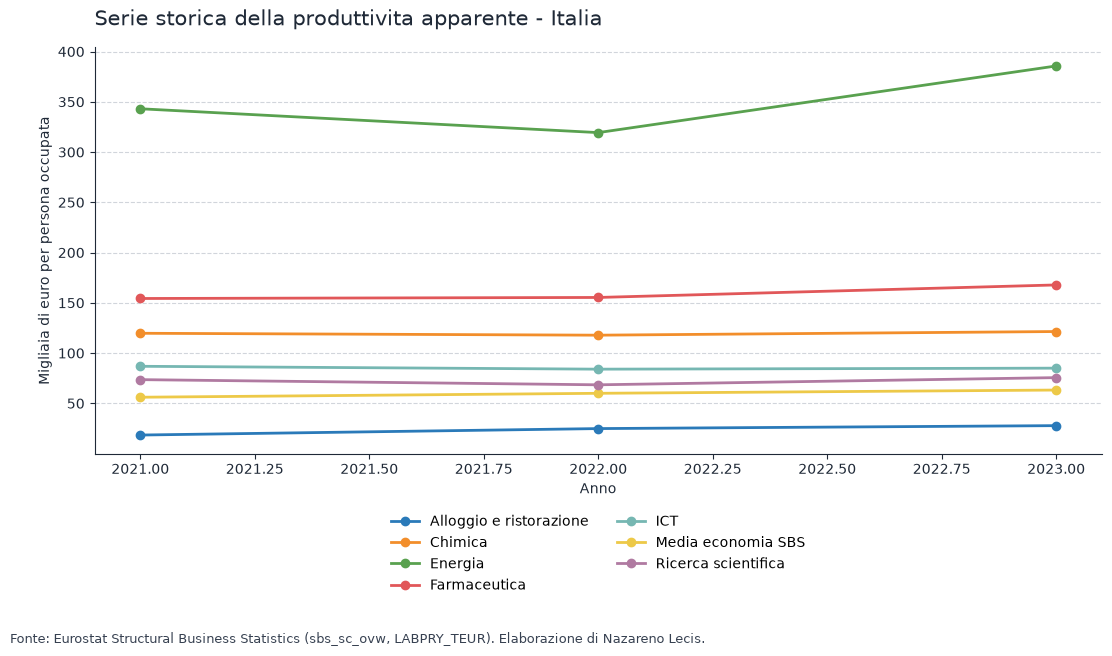

settore,Alloggio e ristorazione,Chimica,Energia,Farmaceutica,ICT,Media economia SBS,Ricerca scientifica
year,,,,,,,
2021,18.40,119.70,343.10,154.30,86.90,56.10,73.60
2022,24.90,117.80,319.40,155.30,84.00,60.00,68.40
2023,27.80,121.40,385.70,167.80,85.00,63.20,75.60


In [9]:
serie_codici = ["D", "C21", "C20", "J", "M72", "B-S_X_O_S94", "I"]
serie_storica = produttivita_totale.query(
    "country_code == @ITALIA and sector_code_original in @serie_codici"
).copy()
serie_storica["settore"] = serie_storica["sector_code_original"].map(settori_selezionati).fillna(serie_storica["sector_label"])

fig, ax = plt.subplots(figsize=(13, 7))
for indice, (settore, gruppo) in enumerate(serie_storica.groupby("settore", observed=True)):
    gruppo = gruppo.sort_values("year")
    ax.plot(gruppo["year"], gruppo["value"], marker="o", linewidth=2, label=settore, color=COLORI[indice % len(COLORI)])

rifinisci_grafico(
    ax,
    "Serie storica della produttivita apparente - Italia",
    "Migliaia di euro per persona occupata",
)
ax.set_xlabel("Anno")
ax.legend(frameon=False, ncol=2, loc="upper center", bbox_to_anchor=(0.5, -0.12))
aggiungi_fonte(ax)
fig.subplots_adjust(bottom=0.30)
plt.show()

serie_storica.pivot_table(
    index="year",
    columns="settore",
    values="value",
    aggfunc="first",
    observed=True,
).round(1).tail(10)

## Confronto europeo sul totale SBS

Questa vista usa il codice aggregato `B-S_X_O_S94` per confrontare la produttivita apparente del perimetro SBS tra paesi europei. E una base piu coerente di una somma manuale di settori, perche usa direttamente l'aggregato pubblicato da Eurostat.

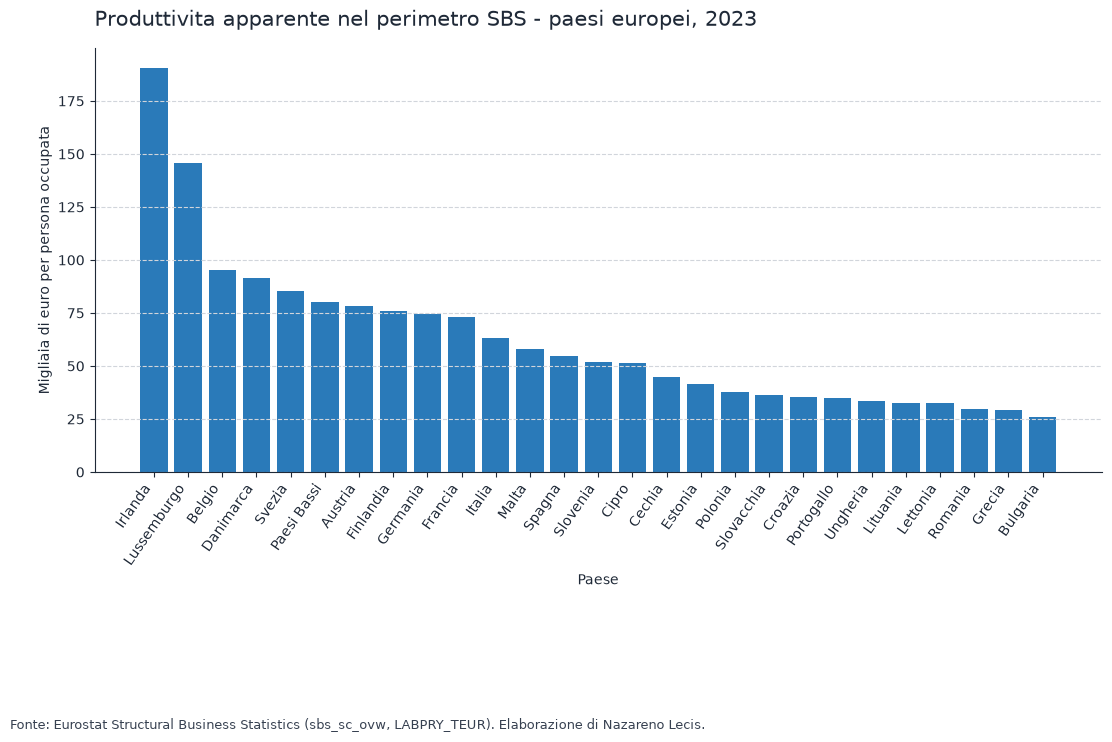

,country_code,country_label,value
41498,IE,Irlanda,190.40
41534,LU,Lussemburgo,145.60
41474,BE,Belgio,95.20
41486,DK,Danimarca,91.40
41578,SE,Svezia,85.30
41546,NL,Paesi Bassi,80.30
41550,AT,Austria,78.30
41574,FI,Finlandia,75.80
41490,DE,Germania,74.50
41510,FR,Francia,73.10


In [10]:
anno_europa = int(produttivita_totale.query("sector_code_original == 'B-S_X_O_S94'")["year"].max())
europa_totale = (
    produttivita_totale.query("sector_code_original == 'B-S_X_O_S94' and year == @anno_europa")
    .loc[:, ["country_code", "country_label", "value"]]
    .dropna(subset=["value"])
    .sort_values("value", ascending=False)
)

fig, ax = plt.subplots(figsize=(13, 8))
ax.bar(europa_totale["country_label"], europa_totale["value"], color="#2a7ab9")
rifinisci_grafico(
    ax,
    f"Produttivita apparente nel perimetro SBS - paesi europei, {anno_europa}",
    "Migliaia di euro per persona occupata",
)
ax.set_xlabel("Paese")
ax.tick_params(axis="x", rotation=55)
for label in ax.get_xticklabels():
    label.set_horizontalalignment("right")
aggiungi_fonte(ax)
fig.subplots_adjust(bottom=0.35)
plt.show()

europa_totale.round(1)

## Controlli utili per la dashboard

Questi controlli non sostituiscono la pipeline, ma documentano quali codici granulari entrano nel racconto. Sono inclusi per rendere tracciabile la presenza di farmaceutica, turismo proxy, alloggio, ristorazione, agenzie di viaggio e sport.

La presenza del dato non implica che i codici siano sommabili tra loro: `I55` e `I56`, per esempio, sono componenti della sezione `I`.

In [11]:
codici_dashboard = {
    "B-S_X_O_S94": "Media economia SBS",
    "C21": "Farmaceutica",
    "I": "Alloggio e ristorazione",
    "I55": "Alloggio",
    "I56": "Ristorazione",
    "N79": "Agenzie di viaggio e tour operator",
    "R93": "Sport e attivita ricreative",
    "S95": "Riparazione di computer e beni personali",
    "S96": "Altri servizi alla persona",
}

copertura_dashboard = []
for codice, etichetta in codici_dashboard.items():
    subset = produttivita_totale.query("sector_code_original == @codice")
    copertura_dashboard.append(
        {
            "codice": codice,
            "settore": etichetta,
            "paesi_con_dati": subset["country_code"].nunique(),
            "primo_anno": int(subset["year"].min()) if len(subset) else None,
            "ultimo_anno": int(subset["year"].max()) if len(subset) else None,
            "valore_italia_ultimo_anno": subset.query("country_code == @ITALIA and year == @anno_italia_massimo")["value"].iloc[0]
            if len(subset.query("country_code == @ITALIA and year == @anno_italia_massimo"))
            else None,
        }
    )

pd.DataFrame(copertura_dashboard).round(1)

,codice,settore,paesi_con_dati,primo_anno,ultimo_anno,valore_italia_ultimo_anno
0,B-S_X_O_S94,Media economia SBS,27,2021,2023,63.20
1,C21,Farmaceutica,23,2021,2023,167.80
2,I,Alloggio e ristorazione,27,2021,2023,27.80
3,I55,Alloggio,27,2021,2023,52.10
4,I56,Ristorazione,27,2021,2023,21.80
5,N79,Agenzie di viaggio e tour operator,25,2021,2023,46.50
6,R93,Sport e attivita ricreative,26,2021,2023,59.60
7,S95,Riparazione di computer e beni personali,27,2021,2023,27.20
8,S96,Altri servizi alla persona,27,2021,2023,21.50


## Fonti e note metodologiche

- Fonte principale: [Eurostat Structural Business Statistics, dataset `sbs_sc_ovw`](https://ec.europa.eu/eurostat/databrowser/view/sbs_sc_ovw/default/table?lang=en).
- Notebook di riferimento: [value_added_by_macro_sector_italy_eurostat.ipynb](https://github.com/NazarenoLecis/public_economic_data_analysis/blob/main/value_added_by_macro_sector_italy_eurostat.ipynb).
- Repo di lavoro: [Valore_aggiunto_imprese](https://github.com/NazarenoLecis/Valore_aggiunto_imprese).

Note di lettura:

- `LABPRY_TEUR` misura il valore aggiunto per persona occupata in migliaia di euro. La persona occupata non coincide necessariamente con il dipendente: include anche lavoratori indipendenti e altre figure occupate nelle imprese.
- Il valore e una media/rapporto pubblicato dalla fonte, non una grandezza additiva. Non va sommato tra classi dimensionali o settori.
- Il perimetro SBS copre industria, costruzioni e servizi di mercato con esclusioni. Non coincide con l'intera economia nazionale e non coincide con il PIL.
- La sezione `I` e usata come proxy del turismo perche copre alloggio e ristorazione; non e una misura satellite completa del turismo.
- Quando si confrontano sezioni e divisioni NACE bisogna ricordare che le divisioni sono sottoinsiemi delle sezioni. La vista ampia serve per esplorare livelli diversi di dettaglio, non per sommare tutte le barre.
- Elaborazione di Nazareno Lecis.